# Phase and Gain of Annual Harmonic versus mean local temperature
Below I show that over a wide range of climates, you see a robust decrease in the Gain (amplitude of surface temperature / amplitude of SW radiation) with warming. Also, the gradient appears to be approximately constant at all latitudes.

In [1]:
import copy
import sys
import os
import inspect
from matplotlib.lines import Line2D
import scipy.optimize
from scipy.interpolate import CubicSpline, UnivariateSpline
from scipy.ndimage import gaussian_filter1d

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, fit_linear_zero_mean, spline_deriv_periodic
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density, moist_static_energy
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g, radius_earth
from isca_tools.utils import numerical, annual_mean
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, frierson_atmospheric_heating
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff, \
    get_heat_cap_lambda_eff_approx
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic
from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff as get_heat_cap_lambda_eff2
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [2]:
from time import perf_counter


def timed_step(label, func):
    """Run func(), print elapsed time, and return its result."""
    start = perf_counter()
    result = func()
    elapsed = perf_counter() - start
    print(f"{label:<55} {elapsed:8.2f} s")
    return result


get_dmse_dt_xr = utils.wrap_with_apply_ufunc(get_dmse_dt,
                                             input_core_dims=[['time', 'pfull'], ['time', 'pfull'], ['time', 'pfull'],
                                                              ['pfull'], ['time']],
                                             output_core_dims=[['time'], ['time']])

In [147]:
# exp_name = [f"thesis_season/column/depth={i}/k=1_abs=0_2" for i in [5, 20]]
# exp_name = [f"thesis_season/column/depth={i}/odp_const" for i in [5, 20]]
# exp_name = [f"thesis_season/column/depth={i}/wind_moist" for i in [5, 20]]
exp_dir = f'tau_sweep/aquaplanet/depth=1/'
# exp_dir = f'tau_sweep/land/meridional_band/depth=1/bucket_evap/'
odp_vals = [0.6, 0.8, 1, 1.5, 2, 2.5, 3, 3.5]
n_exp = len(odp_vals)
# exp_name = [f"thesis_season/column/depth={i}/no_wind_dry_long_output" for i in [5, 20]]
vars_keep = ['t_surf', 'swdn_sfc', 'sphum']
lat_min = 30
lat_max = 90
ds_base = []
for i, val in tqdm(enumerate(odp_vals), total=n_exp):
    path_use = os.path.join(exp_dir, f"k={str(val).replace('.','_')}")
    ds_use = isca_tools.load_dataset(path_use, first_month_file=25).sel(lat=slice(lat_min, lat_max))[vars_keep]
    ds_use['sphum_col'] = mass_weighted_vertical_integral(ds_use.sphum, ds_use.pfull*100, 'pfull', simpson_method=False)
    ds_base.append(ds_use.load())
odp_vals = xr.DataArray(odp_vals, dims="odp", name='odp')
ds_base = xr.concat(ds_base, dim=odp_vals).squeeze()
if 'land' in exp_dir:
    ds_base = ds_base.sel(lon=slice(150, 210))
ds = utils.get_annual_zonal_mean(ds_base)  # also smooths by 50 days
ds.attrs['depth'] = 1
ds.attrs['heat_capacity'] = get_heat_capacity(c_p_ocean, rho_ocean, ds.depth)

  0%|          | 0/8 [00:00<?, ?it/s]

In [148]:
_, coef_amp, coef_phase = get_fourier_fit_xr(ds.time, ds.t_surf, n_harmonics=1, pad_coefs_phase=True)
_, coef_sw_amp, coef_sw_phase = get_fourier_fit_xr(ds.time, ds.swdn_sfc, n_harmonics=1, pad_coefs_phase=True)
ds['coef_sw_amp'] = np.abs(coef_sw_amp.sel(harmonic=1))
ds['coef_amp'] = np.abs(coef_amp.sel(harmonic=1))
ds['coef_phase'] = coef_phase.sel(harmonic=1)
coef_sw_amp = np.abs(coef_sw_amp.sel(harmonic=1))

f = 1 / (ds.time.size * utils.day_seconds)
omega = 2 * np.pi / (utils.day_seconds * ds.time.size)
ds['heat_cap_multiplier'] = get_heat_capacity(c_p_ocean, rho_ocean,
                                        ds.coef_sw_amp * np.sin(ds.coef_phase) / (2 * np.pi * f) / ds.coef_amp,
                                        True) / ds.depth
ds['heat_capacity_eff'] = ds.heat_capacity * heat_cap_multiplier
ds['lambda_eff'] = ds.coef_sw_amp * np.cos(ds.coef_phase) / ds.coef_amp

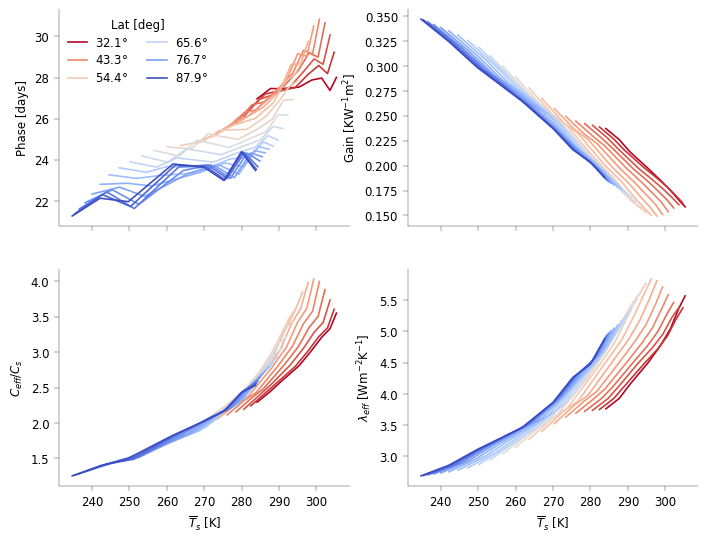

In [160]:
shift_lines = False         # So all cross through the origin, so can see gradient
use_sphum_col = False       # If atmospheric heat capacity is crucial then maybe would expect interesting relation to column sphum
color_lat = plt.colormaps["coolwarm_r"](np.linspace(0, 1, ds.lat.size))
fig, ax = plt.subplots(2, 2, sharex=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
ax = ax.flatten()
for i in range(0, ds.lat.size):
    ds_use = ds.isel(lat=i)
    var = ds_use.t_surf.mean(dim='time')
    if use_sphum_col:
        var = ds_use.sphum_col.mean(dim='time')*1000
    if shift_lines:
        var = var-var.mean(dim='odp')
    var2 = [ds_use.coef_phase / omega / utils.day_seconds, ds_use.coef_amp/ds_use.coef_sw_amp,
            ds_use.heat_cap_multiplier, ds_use.lambda_eff]
    for j in range(len(var2)):
        ax[j].plot(var, var2[j] - var2[j].mean(dim='odp') if shift_lines else var2[j],
                   label=f"{ds_use.lat:.1f}$\degree$" if i%4==0 else None, color=color_lat[i])
ax[0].set_ylabel('Phase [days]')
ax[1].set_ylabel('Gain [KW$^{-1}$m$^2$]')
ax[2].set_ylabel('$C_{eff}/C_s$')
ax[3].set_ylabel('$\\lambda_{eff}$ [Wm$^{-2}$K$^{-1}$]')
if use_sphum_col:
    ax[2].set_xlabel('$\overline{q}_{col}$ [g/kg]')
    ax[3].set_xlabel('$\overline{q}_{col}$ [g/kg]')
else:
    ax[2].set_xlabel('$\overline{T}_s$ [K]')
    ax[3].set_xlabel('$\overline{T}_s$ [K]')
update_linewidth(fig)
ax[0].legend(ncol=2, title='Lat [deg]')
update_fontsize(fig, 7.2)
plt.show()